# Transfer Learning

Consideriamo il fashion MNIST, il dataset di immagini di capi di abbigliamento.
Costruiamo due dataset:
- X_train_A: tutte le immagini eccetto quelle di T-shirt e pullover (classi 0 e 2).git commit -m "Fix: rimossa la cartella tf_env e aggiornato .gitignore"
- X_train_B: un dataset molto più piccolo consistente nelle prime 200 immagini delle classi T-shirt e pullover (classi 0 e 2, escluse prima).

Vogliamo costruire due modelli A e B:
- modello A: classificazione multi-classe con rete neurale densa
- modello B: classificazione binaria delle classi T-shirt vs pullover.

Per il modello B, procederemo per due vie parallele: 
- Definiamo ed addestriamo una Neural Network (NN) da zero ("from scratch")
- Transfer learning: prendiamo alcuni layer del modello A, addestrato per un problema molto simile, e a questi aggiungiamo nuovi layer. I primi layer "vecchi" avranno momentaneamente dei pesi congelati, e faremo un training iniziale solo sui "nuovi" layer aggiunti alla fine della rete. Infine, faremo un fine-tuning (training) su tutta la rete. Si fa solitamente con un learning rate più basso per non cambiare troppo i pesi.

In [1]:
import numpy as np
import keras.layers
import tensorflow as tf

In [2]:
# Importiamo il dataset da Tensorflow
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [3]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dividiamo il dataset in A e B, con una funzione custom.

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]


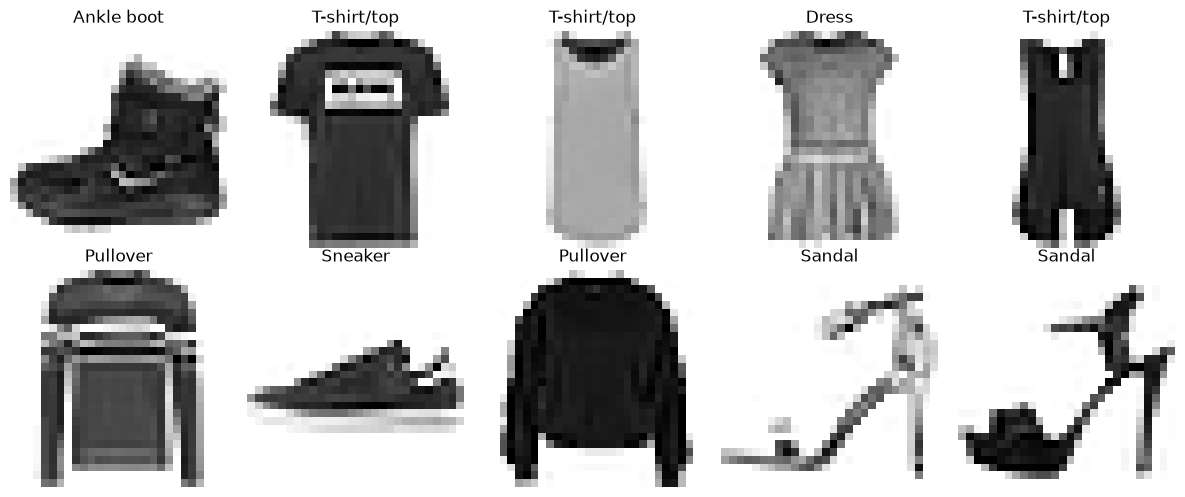

In [4]:
import matplotlib.pyplot as plt

# Stampa una decina di immagini dal dataset di training
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="binary")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [32]:
# Creiamo il modello A ottimizzato
model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# Early stopping per ripristinare i pesi migliori prima che la val_loss salga
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=4, 
    restore_best_weights=True
)

history_A = model_A.fit(
    X_train_A, y_train_A, 
    epochs=20, 
    validation_data=(X_valid_A, y_valid_A),
    callbacks=[early_stopping]
)

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8511 - loss: 0.4117 - val_accuracy: 0.9012 - val_loss: 0.2913
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9022 - loss: 0.2750 - val_accuracy: 0.9118 - val_loss: 0.2465
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9139 - loss: 0.2463 - val_accuracy: 0.9223 - val_loss: 0.2285
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9189 - loss: 0.2269 - val_accuracy: 0.9193 - val_loss: 0.2281
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9230 - loss: 0.2138 - val_accuracy: 0.9218 - val_loss: 0.2233
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9263 - loss: 0.2078 - val_accuracy: 0.9235 - val_loss: 0.2234
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9309 - loss: 0.1927 - val_accuracy: 0.9228 - val_loss: 0.2271
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9324 - loss: 0.1880 - 

In [33]:
# Salviamo il modello e i suoi pesi in locale
model_A.save("my_model_A.keras")

## Modello B

In [34]:
# Creiamo ed addestriamo da zero il modello B (con regolarizzazione)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dropout(0.3),  # Spegne casualmente il 30% dei neuroni
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# Callback per fermare l'addestramento quando la val_loss inizia a salire
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=4, 
    restore_best_weights=True
)

history_B = model_B.fit(
    X_train_B, y_train_B, 
    epochs=20,
    validation_data=(X_valid_B, y_valid_B),
    callbacks=[early_stopping]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8700 - loss: 0.3779 - val_accuracy: 0.9525 - val_loss: 0.1605
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9700 - loss: 0.1282 - val_accuracy: 0.9416 - val_loss: 0.2099
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9550 - loss: 0.1367 - val_accuracy: 0.9555 - val_loss: 0.1275
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9700 - loss: 0.1067 - val_accuracy: 0.9575 - val_loss: 0.1369
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9750 - loss: 0.0867 - val_accuracy: 0.9545 - val_loss: 0.1791
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9800 - loss: 0.0723 - val_accuracy: 0.9575 - val_loss: 0.1319
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9850 - loss: 0.0602 - val_accuracy: 0.9585 - val_loss: 0.1312



Ora proviamo a riusare alcuni layer del modello A che è già stato addestrato.

In [17]:
model_A = tf.keras.models.load_model("my_model_A.keras")

# Cloniamo il modello, in modo da non condividere i pesi con il modello originale
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

# Creiamo ora il modello B a partire dal modello A, clonando tutti i layer tranne l'ultimo
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid")) # classificazione binaria

# Congeliamo tutti i layer tranne l'ultimo
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

# E' importante compilare/configurare ogni volta il modello dopo aver modificato i layer trainabili
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [35]:
import tensorflow as tf

# 1. Caricamento e clonazione sicura del Modello A
model_A = tf.keras.models.load_model("my_model_A.keras")
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

# 2. Costruzione del Modello B riutilizzando i layer clonati di A
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dropout(0.3))
model_B_on_A.add(tf.keras.layers.Dense(
    1, 
    activation="sigmoid", 
    kernel_regularizer=tf.keras.regularizers.l2(0.01)
))

# 3. FASE 1: Congelamento dei layer di base e addestramento della testa
for layer in model_B_on_A.layers[:-2]: # Congela fino al Dropout escluso
    layer.trainable = False

model_B_on_A.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history_B_on_A_frozen = model_B_on_A.fit(
    X_train_B, y_train_B, 
    epochs=5,
    validation_data=(X_valid_B, y_valid_B)
)

# 4. FASE 2: Fine-Tuning sbloccando tutti i layer
for layer in model_B_on_A.layers:
    layer.trainable = True

model_B_on_A.compile(
    loss="binary_crossentropy", 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=3, 
    restore_best_weights=True
)

history_B_on_A_fine_tune = model_B_on_A.fit(
    X_train_B, y_train_B, 
    epochs=20,
    validation_data=(X_valid_B, y_valid_B),
    callbacks=[early_stopping]
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6950 - loss: 0.7816 - val_accuracy: 0.7300 - val_loss: 0.5401
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6750 - loss: 0.6811 - val_accuracy: 0.8655 - val_loss: 0.4662
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7050 - loss: 0.6418 - val_accuracy: 0.9011 - val_loss: 0.4181
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7450 - loss: 0.5264 - val_accuracy: 0.9041 - val_loss: 0.3884
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7850 - loss: 0.5137 - val_accuracy: 0.8981 - val_loss: 0.3705
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8150 - loss: 0.4716 - val_accuracy: 0.9001 - val_loss: 0.3679
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7900 - loss: 0.4653 - val_accuracy: 0.9011 - val_loss: 0.3655
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7850 - loss: 0.4610 - val_accuracy: 0.9001 - val_loss: 0.3632
Epoch

In [38]:
# Salviamo performance di test
# ...

# Valutazione del modello B addestrato da zero
eval_B = model_B.evaluate(X_test_B, y_test_B)

# Valutazione del modello B ottenuto con Transfer Learning
eval_B_on_A = model_B_on_A.evaluate(X_test_B, y_test_B)

# Salviamo la metrica di accuracy per la stampa finale
test_acc_B = eval_B[1]
test_acc_B_on_A = eval_B_on_A[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9530 - loss: 0.1664
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.9060 - loss: 0.3247


In [42]:
# Stampa delle performance con e senza transfer learning
# ...

print(f"Accuracy Modello B (da zero):        {test_acc_B:.4f} (Loss: {eval_B[0]:.4f})")
print(f"Accuracy Modello B_on_A (Transfer):  {test_acc_B_on_A:.4f} (Loss: {eval_B_on_A[0]:.4f})")
print(f"Delta Accuracy:                     {(test_acc_B_on_A - test_acc_B) * 100:+.2f}%\n")

Accuracy Modello B (da zero):        0.9530 (Loss: 0.1664)
Accuracy Modello B_on_A (Transfer):  0.9060 (Loss: 0.3247)
Delta Accuracy:                     -4.70%

